In [21]:
import subprocess
import sys

def install_if_missing(package):
    """Check if package is installed, if not install it."""
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install packages
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('pylab')
install_if_missing('IPython')

# Now import them
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

import time
import math

import pylab as py
from IPython.display import HTML

In [22]:
class Body:
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = position
        self.velocity = velocity

    def copy(self):
        return Body(self.mass, self.position[:], self.velocity[:])

In [23]:
#parameters
G = 6.673e-11 #N m^2 / kg^2

M_Earth  = 6.0e24
M_oculus = 1.0 #kg
M_lux = 0.5 #kg

R_earth = 6371e3 #m
R_orbit = 100e6 #m

d_spacecraft = 0 #m

orbit_inclination = 51.6 * math.pi / 180 # radians

orientation_polar = 90 * math.pi / 180 # radians

orientation_azimuthal = 0 #

N_steps = 50000

v_spacecraft_0 = math.sqrt(G*M_Earth/R_orbit) # m/s

In [ ]:
from astropy.coordinates import get_body_barycentric_posvel
from astropy.time import Time

# Constants
G = 6.673e-11
M_Earth = 6.0e24
R_Earth = 6371e3
J2 = 1.08263e-3
AU = 1.496e11          # metres
P_SRP_1AU = 4.56e-6    # N/m² at 1 AU
C_R = 1.4              # reflectivity coefficient
A_SC = 20.0            # cross-sectional area (m²), adjust per spacecraft
m_SC = 500.0           # spacecraft mass (kg)

# Gravitational params (GM)
GM_Moon = 4.9048695e12
GM_Sun  = 1.32712440018e20

def computeAllAccelerations(sc_pos_gcrf, t_epoch, r_moon_gcrf, r_sun_gcrf):
    """
    sc_pos_gcrf : spacecraft position in Geocentric frame (m)
    r_moon_gcrf : Moon position in Geocentric frame (m)
    r_sun_gcrf  : Sun position in Geocentric frame (m)
    """
    r = np.linalg.norm(sc_pos_gcrf)

    # 1. Earth central gravity
    a_earth = -G * M_Earth / r**3 * sc_pos_gcrf

    # 2. J2 oblateness
    x, y, z = sc_pos_gcrf
    factor = 1.5 * J2 * G * M_Earth * R_Earth**2 / r**5
    a_J2 = factor * np.array([
        x * (5*z**2/r**2 - 1),
        y * (5*z**2/r**2 - 1),
        z * (5*z**2/r**2 - 3)
    ])

    # 3. Moon third-body
    r_moon_sc = r_moon_gcrf - sc_pos_gcrf
    a_moon = GM_Moon * (
        r_moon_sc / np.linalg.norm(r_moon_sc)**3
        - r_moon_gcrf / np.linalg.norm(r_moon_gcrf)**3
    )

    # 4. Sun third-body
    r_sun_sc = r_sun_gcrf - sc_pos_gcrf
    a_sun = GM_Sun * (
        r_sun_sc / np.linalg.norm(r_sun_sc)**3
        - r_sun_gcrf / np.linalg.norm(r_sun_gcrf)**3
    )

    # 5. Solar Radiation Pressure
    dist_sun = np.linalg.norm(r_sun_sc)
    P_srp = P_SRP_1AU * (AU / dist_sun)**2
    sun_dir = r_sun_sc / dist_sun  # unit vector toward Sun
    a_srp = (P_srp * C_R * A_SC / m_SC) * sun_dir  # pushes away from Sun

    return a_earth + a_J2 + a_moon + a_sun + a_srp


In [24]:
r_oculus_0 = np.array([R_orbit*np.cos(orbit_inclination), 0, R_orbit*np.sin(orbit_inclination)])
v_oculus_0 = np.array([0, v_spacecraft_0, 0])

r_lux_0 = r_oculus_0 + np.array([d_spacecraft*np.cos(orientation_polar)*math.cos(orientation_azimuthal), d_spacecraft*np.cos(orientation_polar)*math.sin(orientation_azimuthal), d_spacecraft*np.sin(orientation_polar)])
v_lux_0 = v_oculus_0 + np.array([0, 0, 0]) # Assuming same velocity for simplicity

orbital_normal_vector = np.array([-np.sin(orbit_inclination), 0, np.cos(orbit_inclination)]) # Assuming normal vector along z-axis for simplicity

In [25]:
T_orbit = 2*math.pi*R_orbit/v_spacecraft_0
dt = T_orbit / N_steps
t = np.linspace(0, T_orbit, N_steps)

In [26]:
def compute_gravitational_acceleration(position):
    r = np.linalg.norm(position)
    return -G * M_Earth / r**3 * position

def update_position_velocity(body, dt):
    # Compute acceleration
    acceleration = compute_gravitational_acceleration(body.position)
    
    # Update velocity (using simple Euler method)
    body.velocity += acceleration * dt
    
    # Update position
    body.position += body.velocity * dt

In [27]:
# fixed inertial offset imposed by the constraint
d0 = r_lux_0 - r_oculus_0

oculus = Body(M_oculus, r_oculus_0, v_oculus_0)
lux = Body(M_lux, r_lux_0, v_lux_0)

r_oculus = np.zeros((N_steps, 3))
v_oculus = np.zeros((N_steps, 3))
r_lux = np.zeros((N_steps, 3))
v_lux = np.zeros((N_steps, 3))
a_oculus = np.zeros((N_steps, 3))
a_lux = np.zeros((N_steps, 3))
dv_oculus = np.zeros((N_steps, 3))
dv_lux = np.zeros((N_steps, 3))
F_oculus = np.zeros((N_steps, 3))
F_lux = np.zeros((N_steps, 3))
F_lux_grav = np.zeros((N_steps, 3))
F_lux_constraint = np.zeros((N_steps, 3))

for i in range(1, N_steps):
    r = oculus.position.copy()
    v = oculus.velocity.copy()

    def acc_grav(r_vec):
        return compute_gravitational_acceleration(r_vec)

    # ---------- RK4 stage 1 ----------
    r1_o = r
    v1_o = v
    a1_o = acc_grav(r1_o)

    r1_l = r1_o + d0
    v1_l = v1_o
    a1_l_grav = acc_grav(r1_l)
    a1_l_req = a1_o
    a1_l_con = a1_l_req - a1_l_grav

    k1r = v1_o
    k1v = a1_o

    # ---------- RK4 stage 2 ----------
    r2_o = r + 0.5 * dt * k1r
    v2_o = v + 0.5 * dt * k1v
    a2_o = acc_grav(r2_o)

    r2_l = r2_o + d0
    v2_l = v2_o
    a2_l_grav = acc_grav(r2_l)
    a2_l_req = a2_o
    a2_l_con = a2_l_req - a2_l_grav

    k2r = v2_o
    k2v = a2_o

    # ---------- RK4 stage 3 ----------
    r3_o = r + 0.5 * dt * k2r
    v3_o = v + 0.5 * dt * k2v
    a3_o = acc_grav(r3_o)

    r3_l = r3_o + d0
    v3_l = v3_o
    a3_l_grav = acc_grav(r3_l)
    a3_l_req = a3_o
    a3_l_con = a3_l_req - a3_l_grav

    k3r = v3_o
    k3v = a3_o

    # ---------- RK4 stage 4 ----------
    r4_o = r + dt * k3r
    v4_o = v + dt * k3v
    a4_o = acc_grav(r4_o)

    r4_l = r4_o + d0
    v4_l = v4_o
    a4_l_grav = acc_grav(r4_l)
    a4_l_req = a4_o
    a4_l_con = a4_l_req - a4_l_grav

    k4r = v4_o
    k4v = a4_o

    # ---------- Final RK4 update for Oculus ----------
    new_r_o = r + dt * (k1r + 2*k2r + 2*k3r + k4r) / 6.0
    new_v_o = v + dt * (k1v + 2*k2v + 2*k3v + k4v) / 6.0

    # Oculus weighted acceleration
    a_o_rk4 = (a1_o + 2*a2_o + 2*a3_o + a4_o) / 6.0

    # ---------- Final RK4-weighted constrained Lux quantities ----------
    a_l_req_rk4 = (a1_l_req + 2*a2_l_req + 2*a3_l_req + a4_l_req) / 6.0
    a_l_grav_rk4 = (a1_l_grav + 2*a2_l_grav + 2*a3_l_grav + a4_l_grav) / 6.0
    a_l_con_rk4 = (a1_l_con + 2*a2_l_con + 2*a3_l_con + a4_l_con) / 6.0

    # Final constrained Lux state at end of step
    new_r_l = new_r_o + d0
    new_v_l = new_v_o

    # store back into bodies
    oculus.position = new_r_o
    oculus.velocity = new_v_o

    lux.position = new_r_l
    lux.velocity = new_v_l

    # histories
    r_oculus[i] = new_r_o
    v_oculus[i] = new_v_o
    r_lux[i] = new_r_l
    v_lux[i] = new_v_l

    # accelerations
    a_oculus[i] = a_o_rk4
    a_lux[i] = a_l_req_rk4
    dv_oculus[i] = dt * a_o_rk4
    dv_lux[i] = dt * a_l_req_rk4

    # forces
    F_oculus[i] = oculus.mass * a_o_rk4
    F_lux[i] = lux.mass * a_l_req_rk4
    F_lux_grav[i] = lux.mass * a_l_grav_rk4
    F_lux_constraint[i] = lux.mass * a_l_con_rk4


In [28]:
# drop the first entry from each of the position, velocity and force history arrays
r_oculus = r_oculus[4:]
r_lux    = r_lux[4:]
v_oculus = v_oculus[4:]
v_lux    = v_lux[4:]

F_oculus           = F_oculus[4:]
F_lux              = F_lux[4:]
F_lux_grav         = F_lux_grav[4:]
F_lux_constraint   = F_lux_constraint[4:4+N_steps-4]

t_plot = t[4:4+N_steps-4]

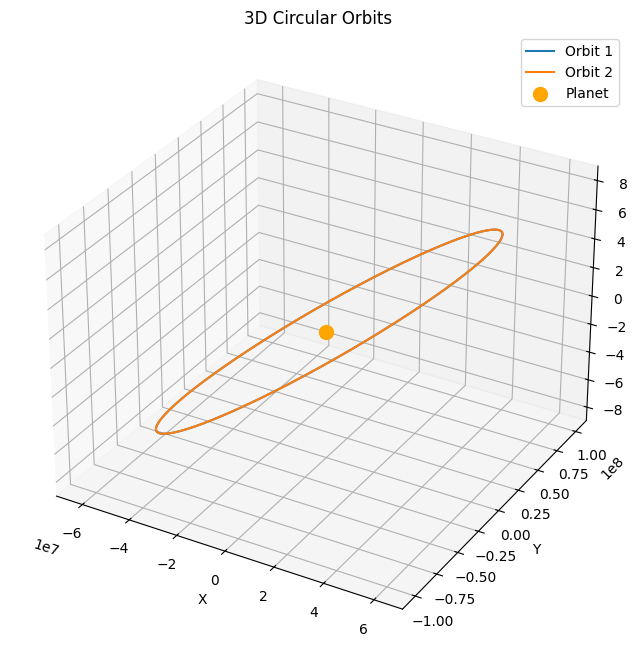

In [29]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(r_oculus[:, 0], r_oculus[:, 1], r_oculus[:, 2], label='Orbit 1')
ax.plot(r_lux[:, 0], r_lux[:, 1], r_lux[:, 2], label='Orbit 2')

# Central body
ax.scatter(0, 0, 0, color='orange', s=100, label='Planet')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Circular Orbits')
ax.legend()

plt.show()

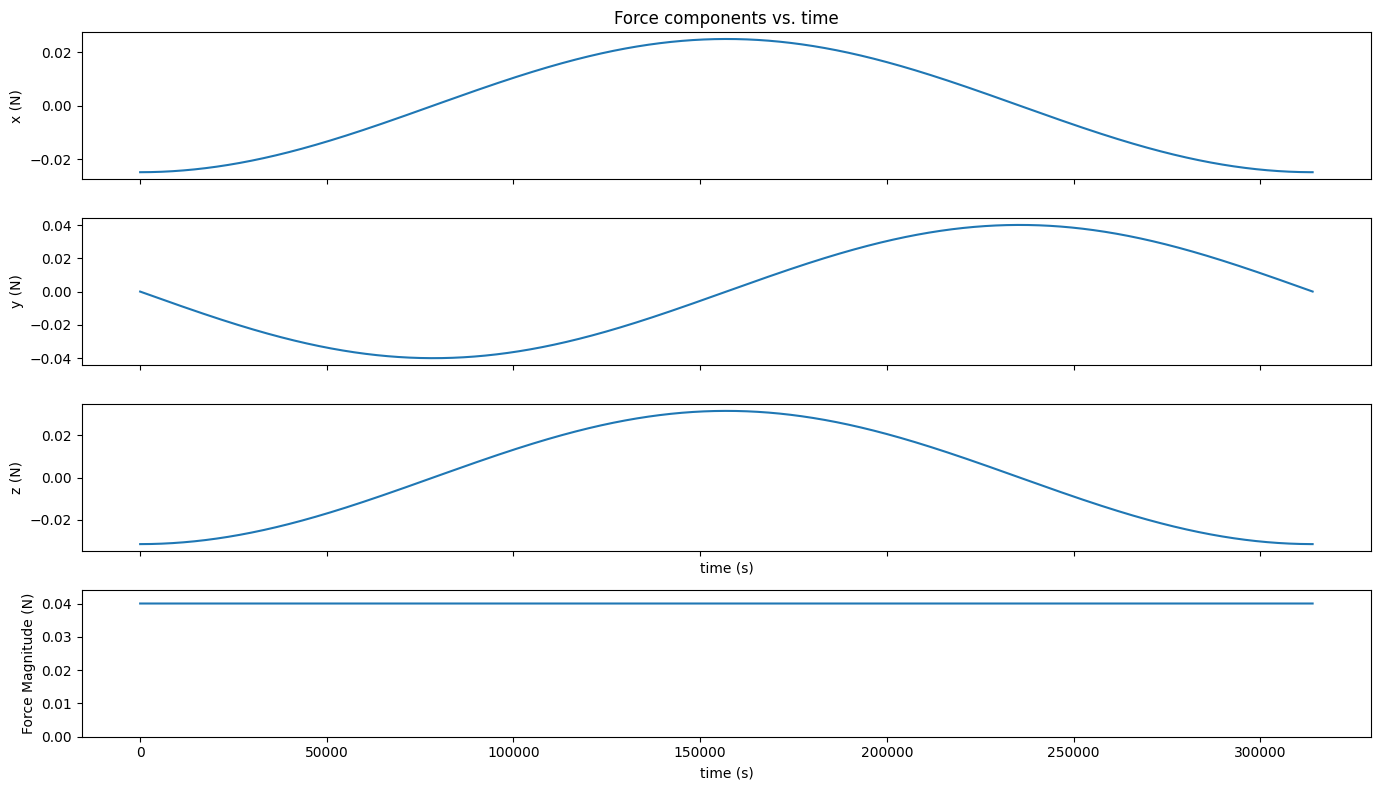

In [30]:
fig, axs = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

axs[0].plot(t_plot, F_oculus[:, 0])
axs[0].set_ylabel('x (N)')  
axs[0].set_title('Force components vs. time')

axs[1].plot(t_plot, F_oculus[:, 1])
axs[1].set_ylabel('y (N)')

axs[2].plot(t_plot, F_oculus[:, 2])
axs[2].set_ylabel('z (N)')
axs[2].set_xlabel('time (s)')

axs[3].plot(t_plot, np.linalg.norm(F_oculus, axis=1), label='Oculus')
axs[3].set_ylabel('Force Magnitude (N)')
axs[3].set_xlabel('time (s)')
axs[3].set_ylim(0, np.max(np.linalg.norm(F_oculus, axis=1))*1.1)

plt.tight_layout()
plt.show()

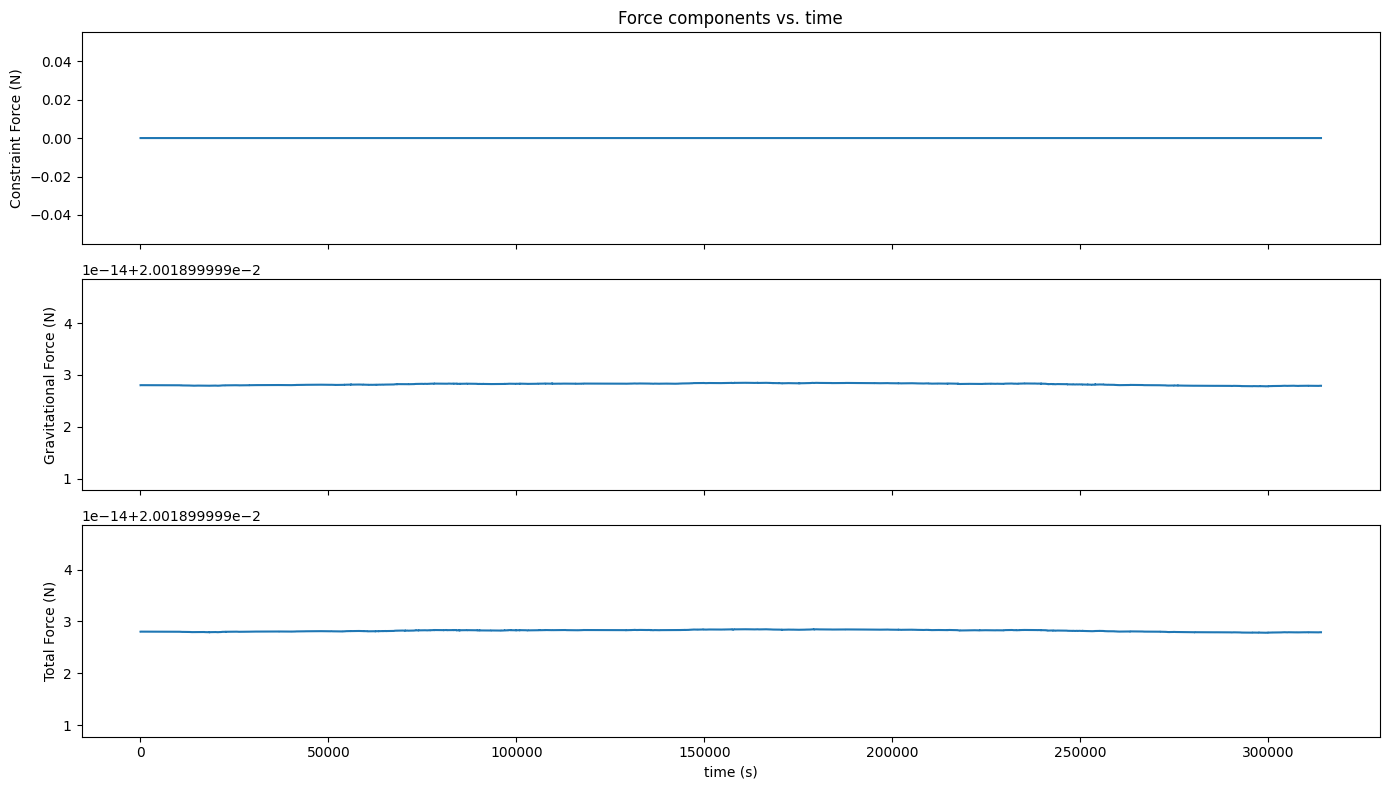

In [31]:
fig, axs = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axs[0].plot(t_plot, np.linalg.norm(F_lux_constraint, axis=1), label='F_lux_constraint_magnitude')
axs[0].set_ylabel('Constraint Force (N)')  
axs[0].set_title('Force components vs. time')


axs[1].plot(t_plot, np.linalg.norm(F_lux_grav, axis=1), label='F_lux_grav_magnitude')
axs[1].set_ylabel('Gravitational Force (N)')

axs[2].plot(t_plot, np.linalg.norm(F_lux, axis=1), label='F_lux_magnitude')
axs[2].set_ylabel('Total Force (N)')
axs[2].set_xlabel('time (s)')
#axs[2].set_ylim(0, np.max(np.linalg.norm(F_lux, axis=1))*1.1)


plt.tight_layout()
plt.show()

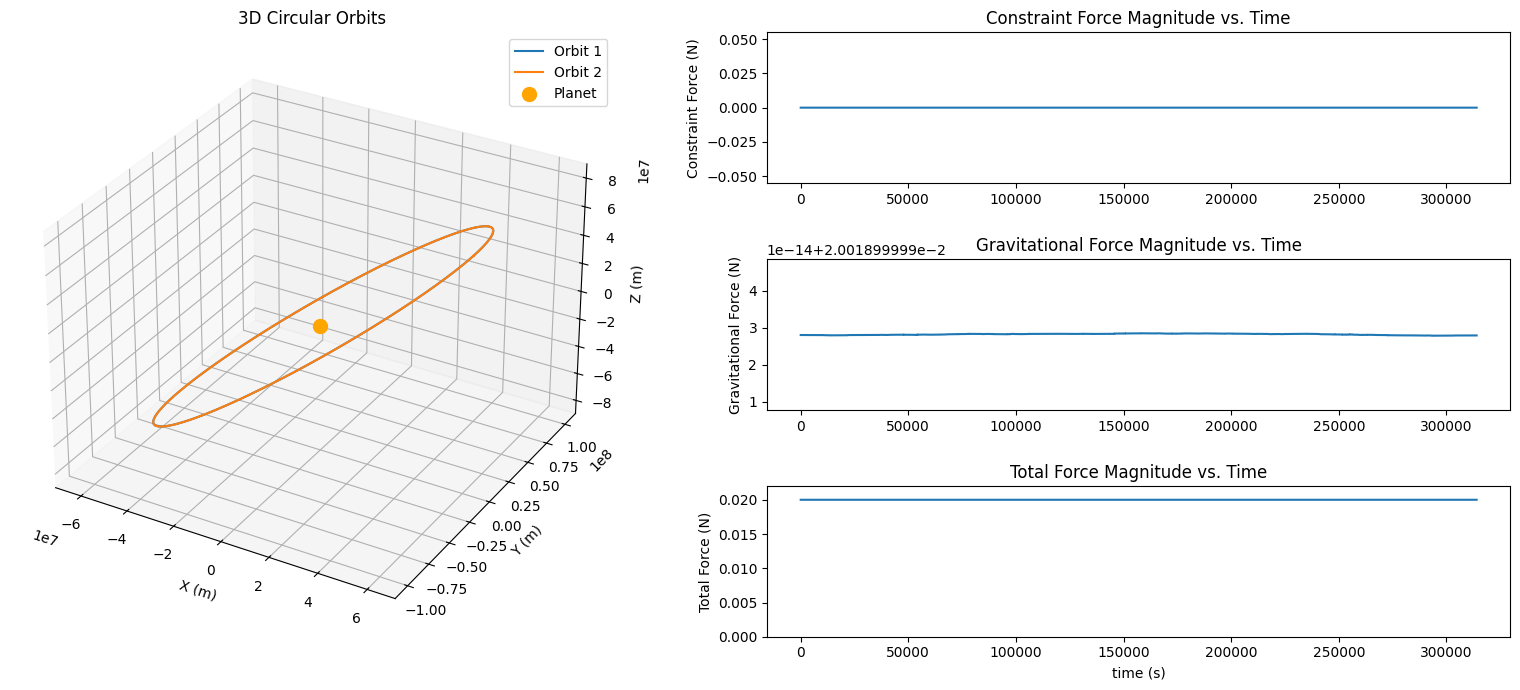

In [32]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(3, 2, figure=fig)

# Left column: 3D orbit plot spanning all 3 rows
ax_left = fig.add_subplot(gs[:, 0], projection='3d')
ax_left.plot(r_oculus[:, 0], r_oculus[:, 1], r_oculus[:, 2], label='Orbit 1')
ax_left.plot(r_lux[:, 0], r_lux[:, 1], r_lux[:, 2], label='Orbit 2')
ax_left.scatter(0, 0, 0, color='orange', s=100, label='Planet')
ax_left.set_xlabel('X (m)')
ax_left.set_ylabel('Y (m)')
ax_left.set_zlabel('Z (m)')
ax_left.set_title('3D Circular Orbits')
ax_left.legend()

# Right column: three separate plots
ax_right1 = fig.add_subplot(gs[0, 1])
ax_right1.plot(t_plot, np.linalg.norm(F_lux_constraint, axis=1), label='F_lux_constraint_magnitude')
ax_right1.set_ylabel('Constraint Force (N)')
ax_right1.set_title('Constraint Force Magnitude vs. Time')

ax_right2 = fig.add_subplot(gs[1, 1])
ax_right2.plot(t_plot, np.linalg.norm(F_lux_grav, axis=1), label='F_lux_grav_magnitude')
ax_right2.set_ylabel('Gravitational Force (N)')
ax_right2.set_title('Gravitational Force Magnitude vs. Time')

ax_right3 = fig.add_subplot(gs[2, 1])
ax_right3.plot(t_plot, np.linalg.norm(F_lux, axis=1), label='F_lux_magnitude')
ax_right3.set_ylabel('Total Force (N)')
ax_right3.set_xlabel('time (s)')
ax_right3.set_title('Total Force Magnitude vs. Time')
ax_right3.set_ylim(0, np.max(np.linalg.norm(F_lux, axis=1))*1.1)

plt.tight_layout()
plt.show()